# Stage 2–4 — Uncertainty-Aware Ensemble Classification
### U-Net-cropped ISIC 2019 → EfficientNet-B3 / ConvNeXt-Small / EfficientNetV2-M
### Weighted Focal Loss · TTA · Weighted Ensemble · Grad-CAM

Run **after** `segmentation-training.ipynb`. This notebook:

1. Loads the trained U-Net and uses it to generate a lesion mask for every ISIC 2019 image.
2. Crops/masks each image around its lesion and caches the processed images to disk.
3. Builds a stratified train/val/test split with a `WeightedRandomSampler` + Weighted Focal
   Loss to handle class imbalance.
4. Trains three ImageNet-pretrained backbones (EfficientNet-B3, ConvNeXt-Small,
   EfficientNetV2-M) with a 3-stage discriminative-learning-rate fine-tuning schedule.
5. Runs Test-Time Augmentation per model, then a validation-tuned weighted ensemble.
6. Produces Grad-CAM explanations, full metrics (Balanced Accuracy, Macro-F1, ROC-AUC,
   confusion matrix, ECE, Brier score), and exports everything needed for a downstream app.

**Kaggle setup**
- Inputs: `ISIC 2019 Dataset Full` **and** the U-Net dataset exported from the segmentation
  notebook (e.g. `unet-lesion-segmentation`).
- Settings → Accelerator: GPU (P100/T4x2), Internet: On.
- This notebook trains 3 large CNNs end-to-end — budget several hours of GPU time, or reduce
  `CONFIG["max_epochs_stage3"]` for a quicker pass.


## 0. Setup

In [1]:

import sys, subprocess, importlib
for pkg, mod in [("timm", "timm"), ("albumentations", "albumentations"), ("grad-cam", "pytorch_grad_cam")]:
    if importlib.util.find_spec(mod) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, json, random, math, copy, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import cv2
cv2.setNumThreads(0)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (balanced_accuracy_score, accuracy_score,
                              precision_recall_fscore_support, roc_auc_score,
                              confusion_matrix, classification_report, brier_score_loss)

warnings.filterwarnings("ignore")

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 86.5 MB/s eta 0:00:00
Using device: cuda


## 1. Configuration

In [2]:

CONFIG = {
    "data_root": "/kaggle/input/datasets/alifshahariar/isic-2019-dataset-full/isic-2019-dataset-full",
    "unet_checkpoint": "/kaggle/input/notebooks/stevedias01/segmentation-skin/artifacts_seg/best_unet.pt",
    "output_dir": "/kaggle/working/artifacts",
    "processed_dir": "/kaggle/working/processed_isic2019",
    "unet_input_size": 384,
    "crop_margin_frac": 0.15,          # 15% margin around the lesion bbox
    "val_fraction": 0.15,
    "test_fraction": 0.15,
    "batch_size": 16,
    "num_workers": 2,
    "melanoma_class": "MEL",

    # focal loss
    "focal_gamma": 2.0,

    # optimizer
    "weight_decay": 1e-4,

    # 3-stage fine-tuning schedule (shared across all 3 backbones)
    "head_lr_stage1": 1e-3,
    "epochs_stage1": 5,                # backbone frozen, head only
    "epochs_stage2": 10,                # unfreeze last 30-40%
    "lr_stage2_head": 1e-4,
    "lr_stage2_backbone": 1e-5,
    "max_epochs_stage3": 60,            # full network, discriminative LR
    "early_stop_patience_stage3": 9,
    "discriminative_lrs": {
        "stem": 1e-6, "early": 2e-6, "middle": 5e-6, "late": 1e-5, "classifier": 3e-5,
    },

    "tta_enabled": True,
    "dropout_p": 0.3,

    "models": [
        {"name": "efficientnet_b3", "timm_name": "efficientnet_b3", "img_size": 300},
        {"name": "convnext_small", "timm_name": "convnext_small", "img_size": 224},
        {"name": "efficientnetv2_m", "timm_name": "tf_efficientnetv2_m", "img_size": 320},
    ],
}

Path(CONFIG["output_dir"]).mkdir(parents=True, exist_ok=True)
Path(CONFIG["processed_dir"]).mkdir(parents=True, exist_ok=True)
DATA_ROOT = Path(CONFIG["data_root"])
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
print(json.dumps({k: v for k, v in CONFIG.items() if k != "discriminative_lrs"}, indent=2))


{
  "data_root": "/kaggle/input/datasets/alifshahariar/isic-2019-dataset-full/isic-2019-dataset-full",
  "unet_checkpoint": "/kaggle/input/notebooks/stevedias01/segmentation-skin/artifacts_seg/best_unet.pt",
  "output_dir": "/kaggle/working/artifacts",
  "processed_dir": "/kaggle/working/processed_isic2019",
  "unet_input_size": 384,
  "crop_margin_frac": 0.15,
  "val_fraction": 0.15,
  "test_fraction": 0.15,
  "batch_size": 16,
  "num_workers": 2,
  "melanoma_class": "MEL",
  "focal_gamma": 2.0,
  "weight_decay": 0.0001,
  "head_lr_stage1": 0.001,
  "epochs_stage1": 5,
  "epochs_stage2": 10,
  "lr_stage2_head": 0.0001,
  "lr_stage2_backbone": 1e-05,
  "max_epochs_stage3": 60,
  "early_stop_patience_stage3": 9,
  "tta_enabled": true,
  "dropout_p": 0.3,
  "models": [
    {
      "name": "efficientnet_b3",
      "timm_name": "efficientnet_b3",
      "img_size": 300
    },
    {
      "name": "convnext_small",
      "timm_name": "convnext_small",
      "img_size": 224
    },
    {
      

## 2. Load labels & U-Net

In [3]:

train_gt = pd.read_csv(DATA_ROOT / "ISIC_2019_Training_GroundTruth.csv")
class_cols = [c for c in train_gt.columns if c not in ("image", "UNK")]
train_gt["label"] = train_gt[class_cols].values.argmax(axis=1)
mel_idx = class_cols.index(CONFIG["melanoma_class"])
print("Classes:", class_cols)
print(train_gt["label"].value_counts().sort_index())

def find_image_path(image_id, split_dir="train"):
    candidates = list((DATA_ROOT / split_dir).rglob(f"{image_id}.jpg"))
    return str(candidates[0]) if candidates else None

train_gt["path"] = train_gt["image"].apply(lambda x: find_image_path(x, "train"))
train_gt = train_gt.dropna(subset=["path"]).reset_index(drop=True)
print(f"Resolved {len(train_gt)} training image paths")


Classes: ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
label
0     4522
1    12875
2     3323
3      867
4     2624
5      239
6      253
7      628
Name: count, dtype: int64
Resolved 25331 training image paths


In [4]:

# --- U-Net (must match the architecture used in segmentation-training.ipynb) ---
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base=32):
        super().__init__()
        chs = [base, base*2, base*4, base*8, base*16]
        self.enc1, self.enc2, self.enc3, self.enc4 = ConvBlock(in_ch, chs[0]), ConvBlock(chs[0], chs[1]), ConvBlock(chs[1], chs[2]), ConvBlock(chs[2], chs[3])
        self.bottleneck = ConvBlock(chs[3], chs[4])
        self.pool = nn.MaxPool2d(2)
        self.up4, self.dec4 = nn.ConvTranspose2d(chs[4], chs[3], 2, stride=2), ConvBlock(chs[4], chs[3])
        self.up3, self.dec3 = nn.ConvTranspose2d(chs[3], chs[2], 2, stride=2), ConvBlock(chs[3], chs[2])
        self.up2, self.dec2 = nn.ConvTranspose2d(chs[2], chs[1], 2, stride=2), ConvBlock(chs[2], chs[1])
        self.up1, self.dec1 = nn.ConvTranspose2d(chs[1], chs[0], 2, stride=2), ConvBlock(chs[1], chs[0])
        self.head = nn.Conv2d(chs[0], out_ch, 1)
    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1)); e3 = self.enc3(self.pool(e2)); e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], 1)); d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1)); d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return self.head(d1)

unet = UNet().to(DEVICE)
unet.load_state_dict(torch.load(CONFIG["unet_checkpoint"], map_location=DEVICE))
unet.eval()
print("U-Net loaded from", CONFIG["unet_checkpoint"])


U-Net loaded from /kaggle/input/notebooks/stevedias01/segmentation-skin/artifacts_seg/best_unet.pt


## 3. Generate lesion masks with U-Net, crop/mask each image

In [5]:

UNET_SIZE = CONFIG["unet_input_size"]

def unet_preprocess(image_rgb):
    h, w = image_rgb.shape[:2]
    scale = UNET_SIZE / max(h, w)
    resized = cv2.resize(image_rgb, (int(w * scale), int(h * scale)))
    pad_h, pad_w = UNET_SIZE - resized.shape[0], UNET_SIZE - resized.shape[1]
    padded = cv2.copyMakeBorder(resized, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)
    norm = (padded / 255.0 - np.array(MEAN)) / np.array(STD)
    tensor = torch.from_numpy(norm.transpose(2, 0, 1)).float().unsqueeze(0)
    return tensor, scale, (h, w)

@torch.no_grad()
def predict_mask(image_rgb):
    tensor, scale, (h, w) = unet_preprocess(image_rgb)
    logits = unet(tensor.to(DEVICE))
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    resized_h, resized_w = int(h * scale), int(w * scale)
    prob_crop = prob[:resized_h, :resized_w]
    mask = cv2.resize(prob_crop, (w, h)) > 0.5
    return mask.astype(np.uint8)

def crop_with_margin(image_rgb, mask, margin_frac=0.15):
    ys, xs = np.where(mask > 0)
    h, w = image_rgb.shape[:2]
    if len(xs) == 0:
        return image_rgb  # U-Net found nothing -> fall back to full image
    x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
    bw, bh = x1 - x0, y1 - y0
    x0 = max(0, int(x0 - bw * margin_frac)); x1 = min(w, int(x1 + bw * margin_frac))
    y0 = max(0, int(y0 - bh * margin_frac)); y1 = min(h, int(y1 + bh * margin_frac))
    return image_rgb[y0:y1, x0:x1]

def process_and_cache(row, out_dir):
    out_path = Path(out_dir) / f"{row['image']}.jpg"
    if out_path.exists():
        return str(out_path)
    image = cv2.cvtColor(cv2.imread(row["path"]), cv2.COLOR_BGR2RGB)
    mask = predict_mask(image)
    cropped = crop_with_margin(image, mask, CONFIG["crop_margin_frac"])
    cv2.imwrite(str(out_path), cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))
    return str(out_path)

processed_train_dir = Path(CONFIG["processed_dir"]) / "train"
processed_train_dir.mkdir(parents=True, exist_ok=True)

processed_paths = []
for _, row in tqdm(train_gt.iterrows(), total=len(train_gt), desc="U-Net crop/mask"):
    processed_paths.append(process_and_cache(row, processed_train_dir))
train_gt["processed_path"] = processed_paths
train_gt.to_csv(Path(CONFIG["output_dir"]) / "train_labels_processed.csv", index=False)
print("Done. Example:", processed_paths[0])


U-Net crop/mask:   0%|          | 0/25331 [00:00<?, ?it/s]

Done. Example: /kaggle/working/processed_isic2019/train/ISIC_0000000.jpg


## 4. Stratified train/val/test split + class weights

In [6]:

train_val_df, test_df = train_test_split(
    train_gt, test_size=CONFIG["test_fraction"], stratify=train_gt["label"], random_state=SEED
)
train_df, val_df = train_test_split(
    train_val_df, test_size=CONFIG["val_fraction"] / (1 - CONFIG["test_fraction"]),
    stratify=train_val_df["label"], random_state=SEED
)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

train_df.to_csv(Path(CONFIG["output_dir"]) / "train_split.csv", index=False)
val_df.to_csv(Path(CONFIG["output_dir"]) / "val_split.csv", index=False)
test_df.to_csv(Path(CONFIG["output_dir"]) / "test_split.csv", index=False)

class_counts = train_df["label"].value_counts().sort_index().values
class_weights = (1.0 / class_counts)
class_weights = class_weights / class_weights.sum() * len(class_cols)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights (alpha for focal loss):", np.round(class_weights, 3))

sample_weights = train_df["label"].map(lambda l: 1.0 / class_counts[l]).values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)


Train: 17731 | Val: 3800 | Test: 3800
Class weights (alpha for focal loss): [0.149 0.052 0.203 0.777 0.257 2.825 2.665 1.072]


## 5. Weighted Focal Loss

In [7]:

class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        alpha_t = self.alpha[targets]
        loss = alpha_t * (1 - pt) ** self.gamma * ce
        return loss.mean()

focal_loss = WeightedFocalLoss(class_weights_t, gamma=CONFIG["focal_gamma"])


## 6. Albumentations transforms & Dataset

In [8]:

def build_transforms(img_size):
    train_tfms = A.Compose([
        A.RandomResizedCrop(size=(img_size, img_size), scale=(0.8, 1.0)),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.15, rotate_limit=25, p=0.5),
        A.CLAHE(p=0.3),
        A.ColorJitter(p=0.3),
        A.GaussNoise(p=0.2),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])
    val_tfms = A.Compose([
        A.Resize(int(img_size * 1.14), int(img_size * 1.14)),
        A.CenterCrop(img_size, img_size),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])
    return train_tfms, val_tfms


class LesionDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.cvtColor(cv2.imread(row["processed_path"]), cv2.COLOR_BGR2RGB)
        image = self.transform(image=image)["image"]
        return image, int(row["label"])


## 7. Three-stage discriminative fine-tuning (shared training function)

Applied identically to each of the three backbones (EfficientNet-B3, ConvNeXt-Small,
EfficientNetV2-M):
- **Stage 1** — freeze backbone, train classifier head only (`epochs_stage1`, `head_lr_stage1`).
- **Stage 2** — unfreeze the last 30–40% of blocks, low LR on backbone / higher on head
  (`epochs_stage2`).
- **Stage 3** — unfreeze everything, discriminative learning rates by depth (stem < early
  < middle < late < classifier), Cosine annealing, AMP, early stopping on validation
  Balanced Accuracy (`max_epochs_stage3`, `early_stop_patience_stage3`).


In [9]:

def build_model(timm_name, num_classes, dropout_p):
    model = timm.create_model(timm_name, pretrained=True, num_classes=num_classes, drop_rate=dropout_p)
    return model.to(DEVICE)


def get_param_groups(model, lrs):
    """Assign params to 5 depth buckets (stem/early/middle/late/classifier) with
    discriminative learning rates. Works generically across timm architectures by
    inspecting parameter name depth order."""
    named = list(model.named_parameters())
    classifier_names = [n for n, _ in named if any(k in n for k in ("head", "classifier", "fc"))]
    backbone_named = [(n, p) for n, p in named if n not in classifier_names]
    n_backbone = len(backbone_named)
    buckets = {"stem": [], "early": [], "middle": [], "late": []}
    for i, (n, p) in enumerate(backbone_named):
        frac = i / max(1, n_backbone - 1)
        if frac < 0.1:
            buckets["stem"].append(p)
        elif frac < 0.4:
            buckets["early"].append(p)
        elif frac < 0.75:
            buckets["middle"].append(p)
        else:
            buckets["late"].append(p)
    classifier_params = [p for n, p in named if n in classifier_names]
    groups = [
        {"params": buckets["stem"], "lr": lrs["stem"]},
        {"params": buckets["early"], "lr": lrs["early"]},
        {"params": buckets["middle"], "lr": lrs["middle"]},
        {"params": buckets["late"], "lr": lrs["late"]},
        {"params": classifier_params, "lr": lrs["classifier"]},
    ]
    return [g for g in groups if len(g["params"]) > 0]


def set_backbone_trainable(model, unfreeze_fraction):
    named = list(model.named_parameters())
    classifier_names = [n for n, _ in named if any(k in n for k in ("head", "classifier", "fc"))]
    backbone_named = [(n, p) for n, p in named if n not in classifier_names]
    n = len(backbone_named)
    cutoff = int(n * (1 - unfreeze_fraction))
    for i, (name, p) in enumerate(backbone_named):
        p.requires_grad = i >= cutoff
    for name, p in named:
        if name in classifier_names:
            p.requires_grad = True


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(images)
            loss = focal_loss(logits, labels)
        total_loss += loss.item() * images.size(0)
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_preds, all_labels = np.concatenate(all_preds), np.concatenate(all_labels)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), bal_acc


def train_one_backbone(model_cfg):
    name, timm_name, img_size = model_cfg["name"], model_cfg["timm_name"], model_cfg["img_size"]
    print(f"\n{'='*70}\nTraining {name} ({timm_name}, {img_size}x{img_size})\n{'='*70}")

    train_tfms, val_tfms = build_transforms(img_size)
    train_ds = LesionDataset(train_df, train_tfms)
    val_ds = LesionDataset(val_df, val_tfms)
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler,
                               num_workers=CONFIG["num_workers"], pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                             num_workers=CONFIG["num_workers"], pin_memory=True)

    model = build_model(timm_name, len(class_cols), CONFIG["dropout_p"])
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
    history = []
    ckpt_path = Path(CONFIG["output_dir"]) / f"best_{name}.pt"

    # ---- Stage 1: frozen backbone, head only ----
    for p in model.parameters():
        p.requires_grad = False
    classifier_names = [n for n, _ in model.named_parameters() if any(k in n for k in ("head", "classifier", "fc"))]
    for n, p in model.named_parameters():
        if n in classifier_names:
            p.requires_grad = True
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                                   lr=CONFIG["head_lr_stage1"], weight_decay=CONFIG["weight_decay"])
    for epoch in range(1, CONFIG["epochs_stage1"] + 1):
        model.train()
        for images, labels in tqdm(train_loader, desc=f"[{name}] stage1 ep{epoch}", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                loss = focal_loss(model(images), labels)
            optimizer.zero_grad(); scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        val_loss, val_bal_acc = evaluate(model, val_loader)
        print(f"  stage1 ep{epoch}: val_loss {val_loss:.4f} val_bal_acc {val_bal_acc:.4f}")
        history.append({"stage": 1, "epoch": epoch, "val_loss": val_loss, "val_bal_acc": val_bal_acc})

    # ---- Stage 2: unfreeze last 30-40% ----
    set_backbone_trainable(model, unfreeze_fraction=0.35)
    param_groups = [
        {"params": [p for n, p in model.named_parameters() if n not in classifier_names and p.requires_grad],
         "lr": CONFIG["lr_stage2_backbone"]},
        {"params": [p for n, p in model.named_parameters() if n in classifier_names], "lr": CONFIG["lr_stage2_head"]},
    ]
    optimizer = torch.optim.AdamW(param_groups, weight_decay=CONFIG["weight_decay"])
    for epoch in range(1, CONFIG["epochs_stage2"] + 1):
        model.train()
        for images, labels in tqdm(train_loader, desc=f"[{name}] stage2 ep{epoch}", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                loss = focal_loss(model(images), labels)
            optimizer.zero_grad(); scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        val_loss, val_bal_acc = evaluate(model, val_loader)
        print(f"  stage2 ep{epoch}: val_loss {val_loss:.4f} val_bal_acc {val_bal_acc:.4f}")
        history.append({"stage": 2, "epoch": epoch, "val_loss": val_loss, "val_bal_acc": val_bal_acc})

    # ---- Stage 3: full network, discriminative LRs, cosine schedule, early stopping ----
    for p in model.parameters():
        p.requires_grad = True
    param_groups = get_param_groups(model, CONFIG["discriminative_lrs"])
    optimizer = torch.optim.AdamW(param_groups, weight_decay=CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["max_epochs_stage3"])

    best_bal_acc, patience_counter = -1.0, 0
    for epoch in range(1, CONFIG["max_epochs_stage3"] + 1):
        model.train()
        for images, labels in tqdm(train_loader, desc=f"[{name}] stage3 ep{epoch}", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                loss = focal_loss(model(images), labels)
            optimizer.zero_grad(); scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        scheduler.step()
        val_loss, val_bal_acc = evaluate(model, val_loader)
        print(f"  stage3 ep{epoch}: val_loss {val_loss:.4f} val_bal_acc {val_bal_acc:.4f}")
        history.append({"stage": 3, "epoch": epoch, "val_loss": val_loss, "val_bal_acc": val_bal_acc})

        if val_bal_acc > best_bal_acc:
            best_bal_acc = val_bal_acc
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"    -> new best val Balanced Accuracy {best_bal_acc:.4f}, checkpoint saved")
        else:
            patience_counter += 1
            if patience_counter >= CONFIG["early_stop_patience_stage3"]:
                print(f"  Early stopping stage 3 at epoch {epoch}")
                break

    pd.DataFrame(history).to_csv(Path(CONFIG["output_dir"]) / f"{name}_training_history.csv", index=False)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    return model, best_bal_acc


## 8. Train all three backbones

In [10]:

trained_models = {}
for model_cfg in CONFIG["models"]:
    model, best_bal_acc = train_one_backbone(model_cfg)
    trained_models[model_cfg["name"]] = {"model": model, "img_size": model_cfg["img_size"], "val_bal_acc": best_bal_acc}
    print(f"{model_cfg['name']} best val Balanced Accuracy: {best_bal_acc:.4f}")



Training efficientnet_b3 (efficientnet_b3, 300x300)


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

[efficientnet_b3] stage1 ep1:   0%|          | 0/1108 [00:00<?, ?it/s]

  stage1 ep1: val_loss 0.3608 val_bal_acc 0.4657


[efficientnet_b3] stage1 ep2:   0%|          | 0/1108 [00:00<?, ?it/s]

...

  stage3 ep37: val_loss 0.0935 val_bal_acc 0.7835


[efficientnetv2_m] stage3 ep38:   0%|          | 0/1108 [00:00<?, ?it/s]

  stage3 ep38: val_loss 0.0983 val_bal_acc 0.7759


[efficientnetv2_m] stage3 ep39:   0%|          | 0/1108 [00:00<?, ?it/s]

  stage3 ep39: val_loss 0.0946 val_bal_acc 0.7820
  Early stopping stage 3 at epoch 39
efficientnetv2_m best val Balanced Accuracy: 0.7948


## 9. Test-Time Augmentation (per model)

In [11]:

TTA_TRANSFORMS = ["original", "hflip", "vflip", "rot90"]

def apply_tta_variant(image_np, variant):
    if variant == "original":
        return image_np
    if variant == "hflip":
        return cv2.flip(image_np, 1)
    if variant == "vflip":
        return cv2.flip(image_np, 0)
    if variant == "rot90":
        return cv2.rotate(image_np, cv2.ROTATE_90_CLOCKWISE)
    raise ValueError(variant)


@torch.no_grad()
def predict_probs_tta(model, df, img_size, tta_enabled=True):
    _, val_tfms = build_transforms(img_size)
    variants = TTA_TRANSFORMS if tta_enabled else ["original"]
    all_probs = np.zeros((len(df), len(class_cols)))
    model.eval()
    for variant in variants:
        variant_probs = []
        loader_paths = df["processed_path"].tolist()
        for i in tqdm(range(0, len(loader_paths), CONFIG["batch_size"]), desc=f"TTA[{variant}]", leave=False):
            batch_paths = loader_paths[i:i + CONFIG["batch_size"]]
            batch_imgs = []
            for p in batch_paths:
                img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
                img = apply_tta_variant(img, variant)
                img = val_tfms(image=img)["image"]
                batch_imgs.append(img)
            batch_t = torch.stack(batch_imgs).to(DEVICE)
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                logits = model(batch_t)
                probs = F.softmax(logits, dim=1).float().cpu().numpy()
            variant_probs.append(probs)
        all_probs += np.concatenate(variant_probs, axis=0)
    return all_probs / len(variants)


member_val_probs, member_test_probs = {}, {}
for name, info in trained_models.items():
    member_val_probs[name] = predict_probs_tta(info["model"], val_df, info["img_size"], CONFIG["tta_enabled"])
    member_test_probs[name] = predict_probs_tta(info["model"], test_df, info["img_size"], CONFIG["tta_enabled"])
    acc = accuracy_score(val_df["label"].values, member_val_probs[name].argmax(1))
    print(f"{name} val accuracy (with TTA): {acc:.4f}")


TTA[original]:   0%|          | 0/238 [00:00<?, ?it/s]

TTA[hflip]:   0%|          | 0/238 [00:00<?, ?it/s]

TTA[vflip]:   0%|          | 0/238 [00:00<?, ?it/s]

TTA[rot90]:   0%|          | 0/238 [00:00<?, ?it/s]

TTA[original]:   0%|          | 0/238 [00:00<?, ?it/s]

...

TTA[original]:   0%|          | 0/238 [00:00<?, ?it/s]

TTA[hflip]:   0%|          | 0/238 [00:00<?, ?it/s]

TTA[vflip]:   0%|          | 0/238 [00:00<?, ?it/s]

TTA[rot90]:   0%|          | 0/238 [00:00<?, ?it/s]

efficientnetv2_m val accuracy (with TTA): 0.7579


## 10. Tune weighted-ensemble weights on the validation set

In [12]:

model_names = list(trained_models.keys())
val_labels = val_df["label"].values
test_labels = test_df["label"].values

def ensemble_bal_acc(weights):
    weights = np.array(weights) / np.sum(weights)
    combined = sum(w * member_val_probs[name] for w, name in zip(weights, model_names))
    return balanced_accuracy_score(val_labels, combined.argmax(1))

best_weights, best_score = None, -1
rng = np.random.default_rng(SEED)
for _ in range(500):
    candidate = rng.dirichlet(np.ones(len(model_names)))
    score = ensemble_bal_acc(candidate)
    if score > best_score:
        best_score, best_weights = score, candidate

print("Best ensemble weights:", dict(zip(model_names, np.round(best_weights, 3))))
print(f"Best validation Balanced Accuracy: {best_score:.4f}")

ensemble_test_probs = sum(w * member_test_probs[name] for w, name in zip(best_weights, model_names))
ensemble_test_preds = ensemble_test_probs.argmax(1)


Best ensemble weights: {'efficientnet_b3': np.float64(0.188), 'convnext_small': np.float64(0.344), 'efficientnetv2_m': np.float64(0.468)}
Best validation Balanced Accuracy: 0.8218


## 11. Grad-CAM explainability

In [13]:

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Use the best single backbone (highest val Balanced Accuracy) for Grad-CAM visualizations
best_single_name = max(trained_models, key=lambda n: trained_models[n]["val_bal_acc"])
best_single_model = trained_models[best_single_name]["model"]
best_single_size = trained_models[best_single_name]["img_size"]
_, val_tfms_best = build_transforms(best_single_size)

def get_target_layer(model, name):
    if "efficientnet" in name:
        return model.conv_head
    if "convnext" in name:
        return model.stages[-1].blocks[-1].conv_dw
    raise ValueError(f"No target layer mapping for {name}")

gradcam_dir = Path(CONFIG["output_dir"]) / "gradcam_audit"
gradcam_dir.mkdir(exist_ok=True)

target_layer = get_target_layer(best_single_model, best_single_name)
cam = GradCAM(model=best_single_model, target_layers=[target_layer])

sample_categories = {
    "correct": np.where(ensemble_test_preds == test_labels)[0],
    "misclassified": np.where(ensemble_test_preds != test_labels)[0],
}

for category, idxs in sample_categories.items():
    if len(idxs) == 0:
        continue
    chosen = np.random.choice(idxs, size=min(3, len(idxs)), replace=False)
    for i in chosen:
        row = test_df.iloc[i]
        img_rgb = cv2.cvtColor(cv2.imread(row["processed_path"]), cv2.COLOR_BGR2RGB)
        img_t = val_tfms_best(image=img_rgb)["image"].unsqueeze(0).to(DEVICE)
        grayscale_cam = cam(input_tensor=img_t)[0]
        img_resized = cv2.resize(img_rgb, (best_single_size, best_single_size)) / 255.0
        overlay = show_cam_on_image(img_resized.astype(np.float32), grayscale_cam, use_rgb=True)
        out_path = gradcam_dir / f"{category}_{row['image']}.png"
        cv2.imwrite(str(out_path), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
print("Grad-CAM examples saved to", gradcam_dir)


Grad-CAM examples saved to /kaggle/working/artifacts/gradcam_audit


## 12. Confusion matrices & classification reports — each model + ensemble (saved as images)

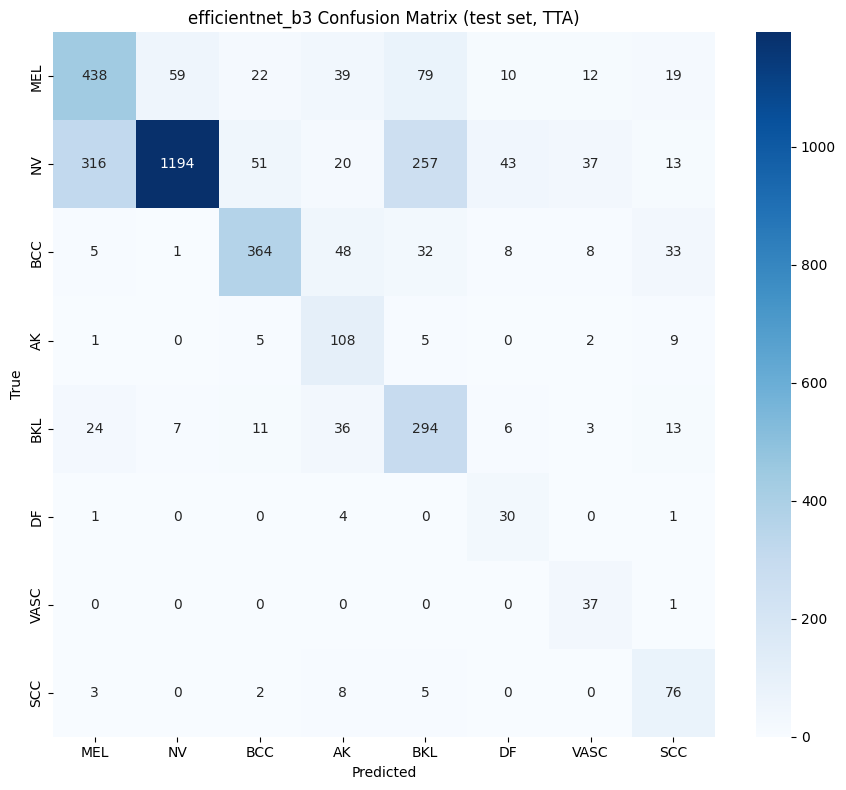

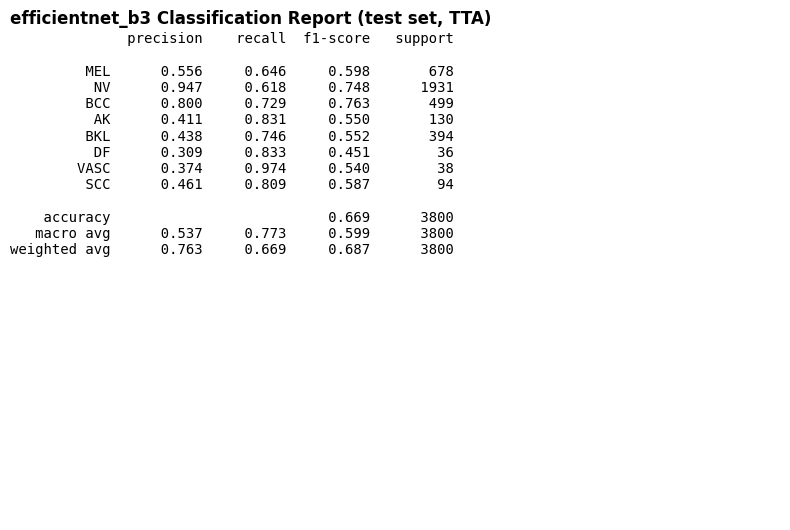


efficientnet_b3 classification report
              precision    recall  f1-score   support

         MEL      0.556     0.646     0.598       678
          NV      0.947     0.618     0.748      1931
         BCC      0.800     0.729     0.763       499
          AK      0.411     0.831     0.550       130
         BKL      0.438     0.746     0.552       394
          DF      0.309     0.833     0.451        36
        VASC      0.374     0.974     0.540        38
         SCC      0.461     0.809     0.587        94

    accuracy                          0.669      3800
   macro avg      0.537     0.773     0.599      3800
weighted avg      0.763     0.669     0.687      3800



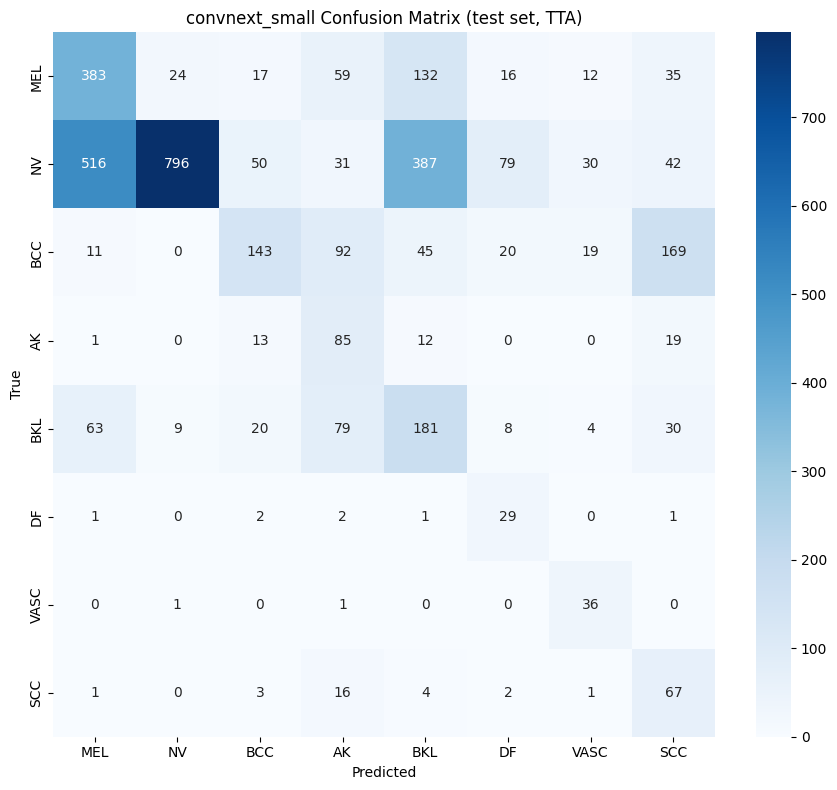

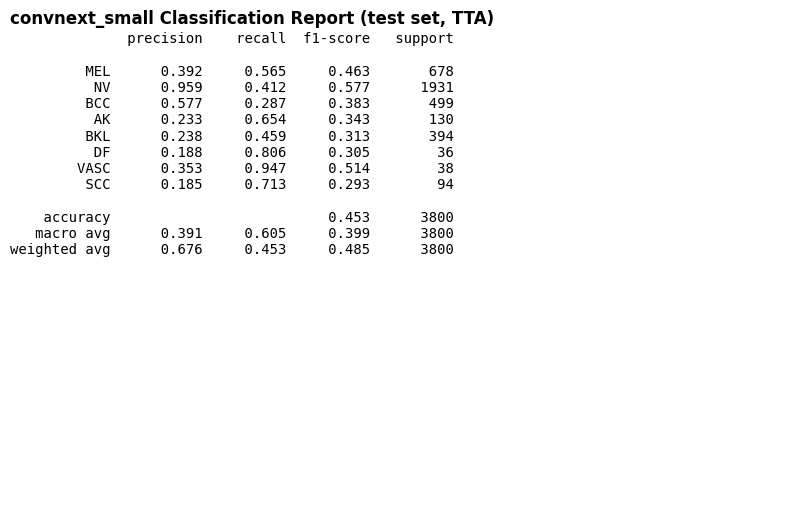


convnext_small classification report
              precision    recall  f1-score   support

         MEL      0.392     0.565     0.463       678
          NV      0.959     0.412     0.577      1931
         BCC      0.577     0.287     0.383       499
          AK      0.233     0.654     0.343       130
         BKL      0.238     0.459     0.313       394
          DF      0.188     0.806     0.305        36
        VASC      0.353     0.947     0.514        38
         SCC      0.185     0.713     0.293        94

    accuracy                          0.453      3800
   macro avg      0.391     0.605     0.399      3800
weighted avg      0.676     0.453     0.485      3800



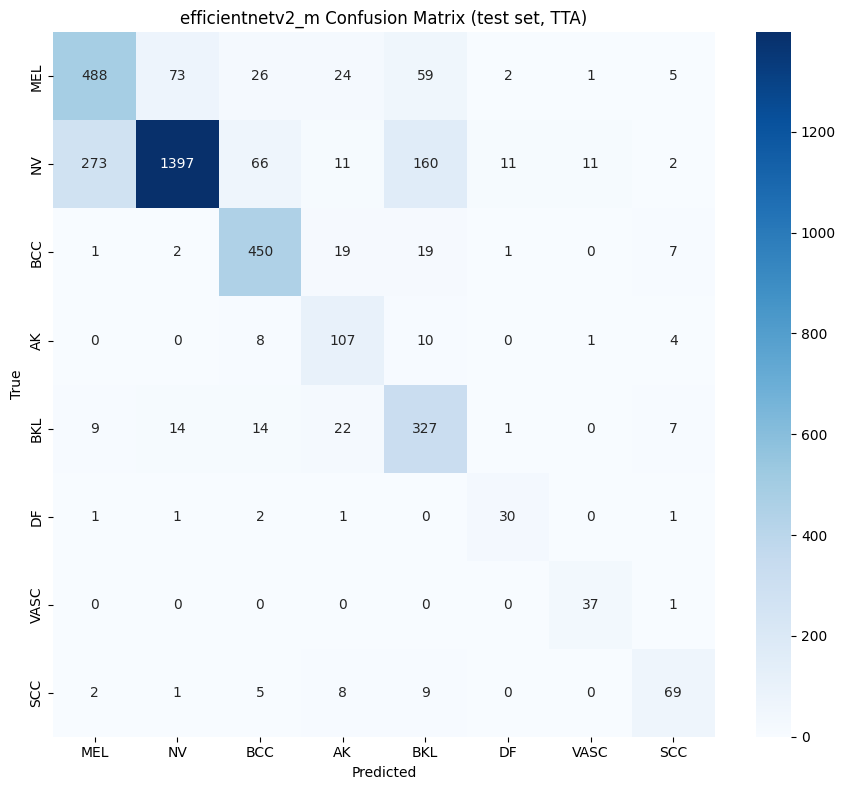

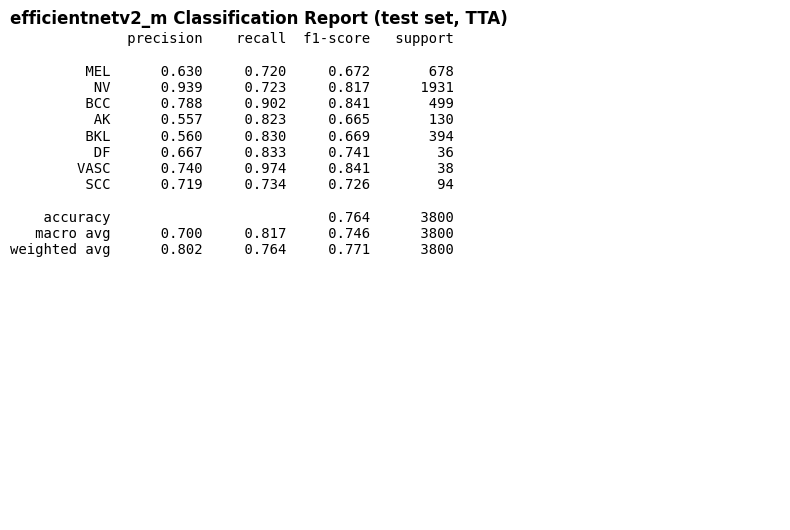


efficientnetv2_m classification report
              precision    recall  f1-score   support

         MEL      0.630     0.720     0.672       678
          NV      0.939     0.723     0.817      1931
         BCC      0.788     0.902     0.841       499
          AK      0.557     0.823     0.665       130
         BKL      0.560     0.830     0.669       394
          DF      0.667     0.833     0.741        36
        VASC      0.740     0.974     0.841        38
         SCC      0.719     0.734     0.726        94

    accuracy                          0.764      3800
   macro avg      0.700     0.817     0.746      3800
weighted avg      0.802     0.764     0.771      3800



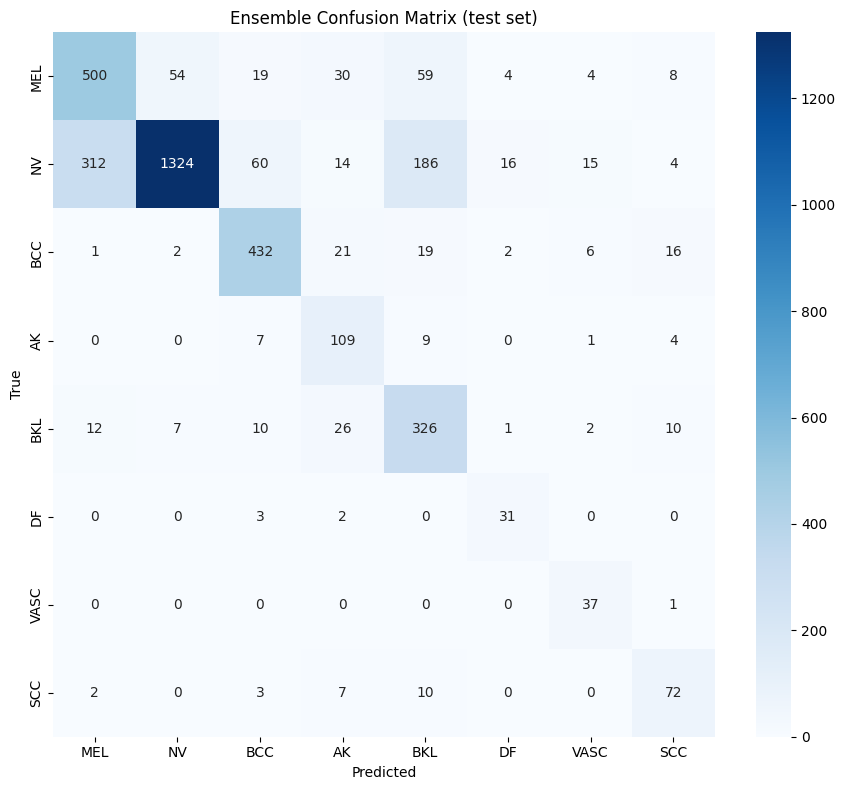

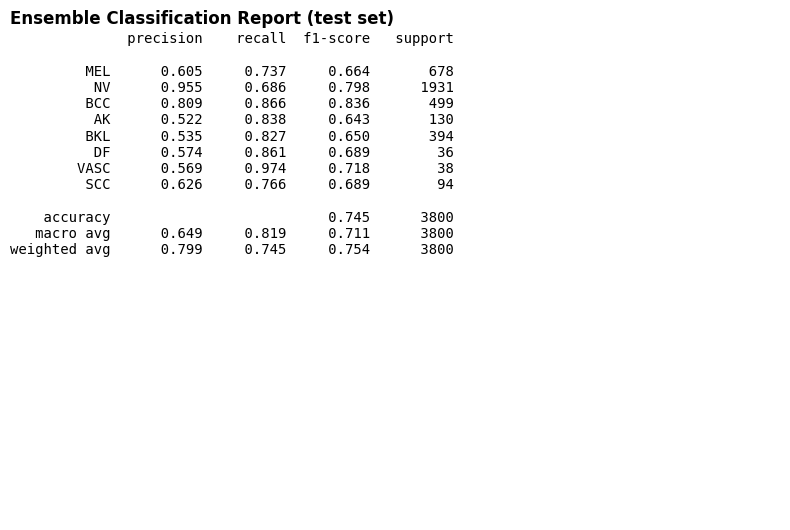


Ensemble classification report
              precision    recall  f1-score   support

         MEL      0.605     0.737     0.664       678
          NV      0.955     0.686     0.798      1931
         BCC      0.809     0.866     0.836       499
          AK      0.522     0.838     0.643       130
         BKL      0.535     0.827     0.650       394
          DF      0.574     0.861     0.689        36
        VASC      0.569     0.974     0.718        38
         SCC      0.626     0.766     0.689        94

    accuracy                          0.745      3800
   macro avg      0.649     0.819     0.711      3800
weighted avg      0.799     0.745     0.754      3800


Saved confusion matrices + classification reports (as .png images) to: /kaggle/working/artifacts/reports


In [14]:

import seaborn as sns

def save_confusion_matrix_image(labels, preds, class_names, title, out_path):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(9, 8))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=120)
    plt.show()
    plt.close()


def save_classification_report_image(labels, preds, class_names, title, out_path):
    report_str = classification_report(labels, preds, target_names=class_names, digits=3, zero_division=0)
    fig, ax = plt.subplots(figsize=(8, 0.45 * (len(class_names) + 4)))
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", loc="left")
    ax.text(0, 1, report_str, family="monospace", fontsize=10, va="top", ha="left")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    return report_str


reports_dir = Path(CONFIG["output_dir"]) / "reports"
reports_dir.mkdir(exist_ok=True)

all_reports = {}

# --- Per-model (TTA) results on the test set ---
for name in model_names:
    preds = member_test_probs[name].argmax(axis=1)
    save_confusion_matrix_image(
        test_labels, preds, class_cols,
        f"{name} Confusion Matrix (test set, TTA)",
        reports_dir / f"confusion_matrix_{name}.png",
    )
    report_str = save_classification_report_image(
        test_labels, preds, class_cols,
        f"{name} Classification Report (test set, TTA)",
        reports_dir / f"classification_report_{name}.png",
    )
    all_reports[name] = report_str
    print(f"\n{'='*60}\n{name} classification report\n{'='*60}")
    print(report_str)

# --- Ensemble ---
save_confusion_matrix_image(
    test_labels, ensemble_test_preds, class_cols,
    "Ensemble Confusion Matrix (test set)",
    reports_dir / "confusion_matrix_ensemble.png",
)
ensemble_report_str = save_classification_report_image(
    test_labels, ensemble_test_preds, class_cols,
    "Ensemble Classification Report (test set)",
    reports_dir / "classification_report_ensemble.png",
)
all_reports["ensemble"] = ensemble_report_str
print(f"\n{'='*60}\nEnsemble classification report\n{'='*60}")
print(ensemble_report_str)

with open(reports_dir / "all_classification_reports.txt", "w") as f:
    for name, report_str in all_reports.items():
        f.write(f"{'='*60}\n{name}\n{'='*60}\n{report_str}\n\n")

print("\nSaved confusion matrices + classification reports (as .png images) to:", reports_dir)


## 13. Full evaluation: Balanced Accuracy, Macro-F1, ROC-AUC, confusion matrix, ECE, Brier

FINAL ENSEMBLE EVALUATION (test set)
Balanced Accuracy : 0.8194
Accuracy          : 0.7450
Macro Precision   : 0.6493
Macro Recall      : 0.8194
Macro F1          : 0.7110
Macro ROC-AUC     : 0.9628
Melanoma Recall   : 0.7375
ECE               : 0.1554
Brier Score       : 0.3994

Per-class recall:
  MEL    0.7375
  NV     0.6857
  BCC    0.8657
  AK     0.8385
  BKL    0.8274
  DF     0.8611
  VASC   0.9737
  SCC    0.7660

Classification report:
              precision    recall  f1-score   support

         MEL      0.605     0.737     0.664       678
          NV      0.955     0.686     0.798      1931
         BCC      0.809     0.866     0.836       499
          AK      0.522     0.838     0.643       130
         BKL      0.535     0.827     0.650       394
          DF      0.574     0.861     0.689        36
        VASC      0.569     0.974     0.718        38
         SCC      0.626     0.766     0.689        94

    accuracy                          0.745      3800
   macr

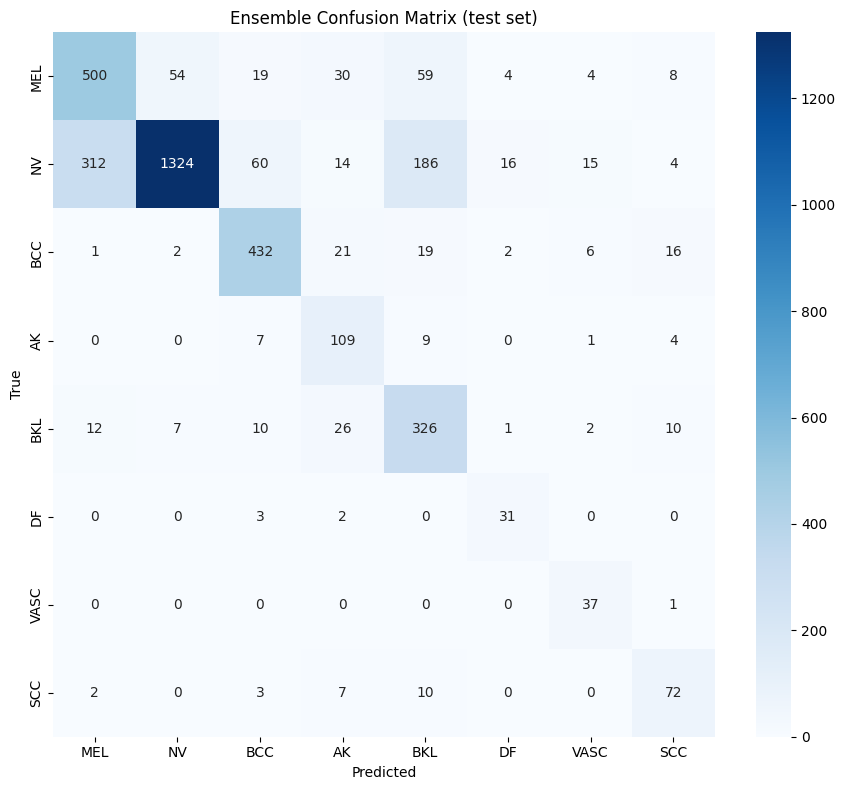

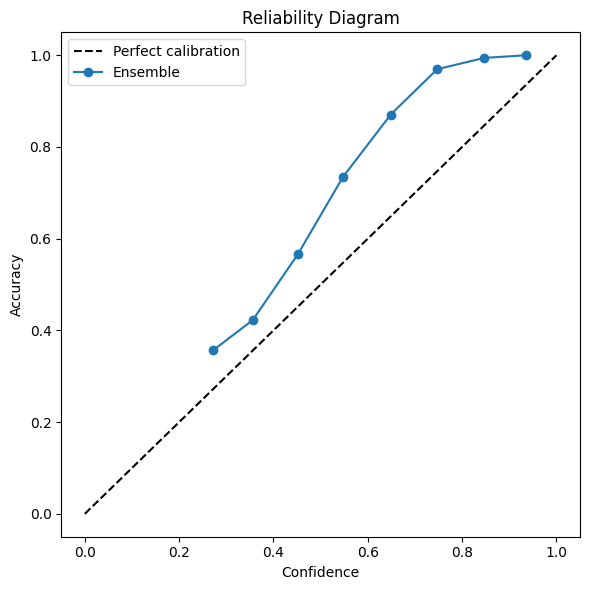

In [15]:

def expected_calibration_error(probs, labels, n_bins=10):
    confidences = probs.max(axis=1)
    preds = probs.argmax(axis=1)
    correct = (preds == labels).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i + 1])
        if mask.sum() == 0:
            continue
        bin_acc = correct[mask].mean()
        bin_conf = confidences[mask].mean()
        ece += (mask.sum() / len(confidences)) * abs(bin_acc - bin_conf)
    return ece


bal_acc = balanced_accuracy_score(test_labels, ensemble_test_preds)
acc = accuracy_score(test_labels, ensemble_test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, ensemble_test_preds, average="macro", zero_division=0)
per_class_recall = precision_recall_fscore_support(test_labels, ensemble_test_preds, average=None, zero_division=0)[1]
roc_auc = roc_auc_score(pd.get_dummies(test_labels), ensemble_test_probs, average="macro", multi_class="ovr")
ece = expected_calibration_error(ensemble_test_probs, test_labels)
brier = np.mean(np.sum((ensemble_test_probs - pd.get_dummies(test_labels).values) ** 2, axis=1))
mel_recall = per_class_recall[mel_idx]

print("="*60)
print("FINAL ENSEMBLE EVALUATION (test set)")
print("="*60)
print(f"Balanced Accuracy : {bal_acc:.4f}")
print(f"Accuracy          : {acc:.4f}")
print(f"Macro Precision   : {precision:.4f}")
print(f"Macro Recall      : {recall:.4f}")
print(f"Macro F1          : {f1:.4f}")
print(f"Macro ROC-AUC     : {roc_auc:.4f}")
print(f"Melanoma Recall   : {mel_recall:.4f}")
print(f"ECE               : {ece:.4f}")
print(f"Brier Score       : {brier:.4f}")

print("\nPer-class recall:")
for cname, r in zip(class_cols, per_class_recall):
    print(f"  {cname:<6} {r:.4f}")

print("\nClassification report:")
print(classification_report(test_labels, ensemble_test_preds, target_names=class_cols, digits=3, zero_division=0))

cm = confusion_matrix(test_labels, ensemble_test_preds)
plt.figure(figsize=(9, 8))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_cols, yticklabels=class_cols, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Ensemble Confusion Matrix (test set)")
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "confusion_matrix.png", dpi=120)
plt.show()

# Reliability diagram
bins = np.linspace(0, 1, 11)
bin_acc, bin_conf = [], []
confidences_all = ensemble_test_probs.max(axis=1)
correct_all = (ensemble_test_preds == test_labels).astype(float)
for i in range(10):
    mask = (confidences_all > bins[i]) & (confidences_all <= bins[i+1])
    if mask.sum() > 0:
        bin_acc.append(correct_all[mask].mean()); bin_conf.append(confidences_all[mask].mean())
    else:
        bin_acc.append(np.nan); bin_conf.append(np.nan)
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(bin_conf, bin_acc, marker="o", label="Ensemble")
plt.xlabel("Confidence"); plt.ylabel("Accuracy"); plt.title("Reliability Diagram"); plt.legend()
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "reliability_diagram.png", dpi=120)
plt.show()

metrics_summary = {
    "balanced_accuracy": bal_acc, "accuracy": acc, "macro_precision": precision,
    "macro_recall": recall, "macro_f1": f1, "macro_roc_auc": roc_auc,
    "melanoma_recall": mel_recall, "ece": ece, "brier_score": brier,
    "per_class_recall": dict(zip(class_cols, per_class_recall.tolist())),
}
with open(Path(CONFIG["output_dir"]) / "metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)


## 14. Export everything for downstream use (e.g. a Streamlit app)

In [16]:

for name, info in trained_models.items():
    # weights already saved as best_<name>.pt during training; just confirm presence
    ckpt = Path(CONFIG["output_dir"]) / f"best_{name}.pt"
    print(name, "->", ckpt, "exists:", ckpt.exists())

with open(Path(CONFIG["output_dir"]) / "config.json", "w") as f:
    json.dump({k: v for k, v in CONFIG.items()}, f, indent=2, default=str)

with open(Path(CONFIG["output_dir"]) / "class_names.json", "w") as f:
    json.dump({"class_names": class_cols, "melanoma_index": int(mel_idx)}, f, indent=2)

with open(Path(CONFIG["output_dir"]) / "ensemble_config.json", "w") as f:
    json.dump({"member_names": model_names,
               "weights": list(map(float, best_weights)),
               "tta_enabled": CONFIG["tta_enabled"]}, f, indent=2)

np.savez(Path(CONFIG["output_dir"]) / "ensemble_test_probs.npz",
          probs=ensemble_test_probs, labels=test_labels, member_names=model_names)

preprocessing_spec = {
    "steps": ["unet_lesion_mask", f"crop_margin_{CONFIG['crop_margin_frac']}",
              "resize+centercrop_per_model", "normalize(imagenet)"],
    "mean": MEAN, "std": STD,
    "per_model_img_size": {m["name"]: m["img_size"] for m in CONFIG["models"]},
}
with open(Path(CONFIG["output_dir"]) / "preprocessing.json", "w") as f:
    json.dump(preprocessing_spec, f, indent=2)

print("\nAll artifacts saved to:", CONFIG["output_dir"])
for p in sorted(Path(CONFIG["output_dir"]).glob("*")):
    print(" -", p.name)


efficientnet_b3 -> /kaggle/working/artifacts/best_efficientnet_b3.pt exists: True
convnext_small -> /kaggle/working/artifacts/best_convnext_small.pt exists: True
efficientnetv2_m -> /kaggle/working/artifacts/best_efficientnetv2_m.pt exists: True

All artifacts saved to: /kaggle/working/artifacts
 - best_convnext_small.pt
 - best_efficientnet_b3.pt
 - best_efficientnetv2_m.pt
 - class_names.json
 - config.json
 - confusion_matrix.png
 - convnext_small_training_history.csv
 - efficientnet_b3_training_history.csv
 - efficientnetv2_m_training_history.csv
 - ensemble_config.json
 - ensemble_test_probs.npz
 - gradcam_audit
 - metrics_summary.json
 - preprocessing.json
 - reliability_diagram.png
 - reports
 - test_split.csv
 - train_labels_processed.csv
 - train_split.csv
 - val_split.csv
